# Paper Results Summary (Multi-Sim)

This notebook summarizes `load_cycle_1` results across multiple simulation seeds (`sim1..sim5`) and reports model-level mean/std.

In [1]:

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = os.path.abspath('.')
SCENARIO = 'load_cycle_1'
PATTERN = os.path.join(BASE_DIR, f"*_observations_{SCENARIO}_sim*.csv")
files = sorted(glob.glob(PATTERN))
print(f"Found {len(files)} files")
for f in files:
    print(os.path.basename(f))


Found 20 files
BASELINE_observations_load_cycle_1_sim1.csv
BASELINE_observations_load_cycle_1_sim2.csv
BASELINE_observations_load_cycle_1_sim3.csv
BASELINE_observations_load_cycle_1_sim4.csv
BASELINE_observations_load_cycle_1_sim5.csv
DQN_observations_load_cycle_1_sim1.csv
DQN_observations_load_cycle_1_sim2.csv
DQN_observations_load_cycle_1_sim3.csv
DQN_observations_load_cycle_1_sim4.csv
DQN_observations_load_cycle_1_sim5.csv
ODT_FINETUNED_observations_load_cycle_1_sim1.csv
ODT_FINETUNED_observations_load_cycle_1_sim2.csv
ODT_FINETUNED_observations_load_cycle_1_sim3.csv
ODT_FINETUNED_observations_load_cycle_1_sim4.csv
ODT_FINETUNED_observations_load_cycle_1_sim5.csv
PPO_observations_load_cycle_1_sim1.csv
PPO_observations_load_cycle_1_sim2.csv
PPO_observations_load_cycle_1_sim3.csv
PPO_observations_load_cycle_1_sim4.csv
PPO_observations_load_cycle_1_sim5.csv


In [2]:

rx = re.compile(r'(?P<model>.+?)_observations_' + re.escape(SCENARIO) + r'_(?P<sim>sim\d+)\.csv$')

runs = []
for fp in files:
    m = rx.match(os.path.basename(fp))
    if not m:
        continue
    model = m.group('model')
    sim = m.group('sim')
    df = pd.read_csv(fp)
    df.columns = [c.strip() for c in df.columns]
    df['model'] = model
    df['sim'] = sim
    runs.append(df)

if not runs:
    raise RuntimeError('No multi-sim CSV files found for the selected scenario.')

all_df = pd.concat(runs, ignore_index=True)
print('Models:', sorted(all_df['model'].unique()))
print('Sims:', sorted(all_df['sim'].unique()))
print('Rows:', len(all_df))
print('Columns:', list(all_df.columns))


Models: ['BASELINE', 'DQN', 'ODT_FINETUNED', 'PPO']
Sims: ['sim1', 'sim2', 'sim3', 'sim4', 'sim5']
Rows: 21640
Columns: ['step', 'lat', 'lon', 'alt', 'snr', 'load', 'handovers', 'allocated_bw', 'allocation_ratio', 'demand_MB', 'throughput_req', 'queing_delay_s', 'propagation_latency_s', 'transmission_rate_mbps', 'latency_req_s', 'beam_capacity', 'service_drop_s', 'dwell_remaining_s', 'ttt_remaining_s', 'model', 'sim']


## 1) Per-Run Metrics

In [3]:

required = [
    'step','snr','handovers','allocated_bw','allocation_ratio','demand_MB',
    'queing_delay_s','propagation_latency_s','transmission_rate_mbps','service_drop_s'
]
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

per_run = (
    all_df
    .groupby(['model','sim'], as_index=False)
    .agg(
        steps=('step','count'),
        allocation_ratio_mean=('allocation_ratio','mean'),
        allocated_bw_mean=('allocated_bw','mean'),
        demand_mb_mean=('demand_MB','mean'),
        transmission_rate_mean=('transmission_rate_mbps','mean'),
        snr_mean=('snr','mean'),
        queue_delay_mean=('queing_delay_s','mean'),
        propagation_latency_mean=('propagation_latency_s','mean'),
        total_latency_mean=('queing_delay_s', lambda s: s.mean()) ,
        service_drop_total=('service_drop_s','sum'),
        service_drop_mean=('service_drop_s','mean'),
        handovers_final=('handovers','max')
    )
)

# Overwrite total latency mean with queue + propagation means
per_run['total_latency_mean'] = per_run['queue_delay_mean'] + per_run['propagation_latency_mean']

per_run = per_run.sort_values(['model','sim']).reset_index(drop=True)
per_run


,model,sim,steps,allocation_ratio_mean,allocated_bw_mean,demand_mb_mean,transmission_rate_mean,snr_mean,queue_delay_mean,propagation_latency_mean,total_latency_mean,service_drop_total,service_drop_mean,handovers_final
0,BASELINE,sim1,1082,0.995504,11.520544,11.566208,18.461422,11.306250,3.704385e+00,0.054791,3.759176,20.276242,0.018740,262.0
1,BASELINE,sim2,1082,0.984620,9.123483,9.246916,14.617159,12.441559,1.390545e+01,0.054669,13.960122,74.010345,0.068401,257.0
2,BASELINE,sim3,1082,0.972456,9.929227,10.204836,15.916129,13.097595,2.682065e+01,0.054753,26.875406,145.174491,0.134172,262.0
3,BASELINE,sim4,1082,0.983184,9.961526,10.180498,15.966361,12.356690,1.342923e+01,0.054523,13.483749,69.652875,0.064374,265.0
4,BASELINE,sim5,1082,0.998908,10.448093,10.464447,16.749762,11.221639,1.128592e-02,0.054579,0.065865,0.000000,0.000000,260.0
5,DQN,sim1,1082,1.000000,11.566208,11.566208,18.533364,11.003605,3.420466e-17,0.054709,0.054709,0.000000,0.000000,249.0
6,DQN,sim2,1082,0.998483,9.234635,9.246916,14.797381,10.958137,4.223645e-02,0.054702,0.096938,0.000000,0.000000,249.0
7,DQN,sim3,1082,1.000000,10.204836,10.204836,16.356839,10.964926,1.250297e-17,0.054738,0.054738,0.000000,0.000000,244.0
8,DQN,sim4,1082,0.996449,10.133772,10.180498,16.244930,11.000335,2.796235e+00,0.054586,2.850821,15.231945,0.014078,248.0
9,DQN,sim5,1082,1.000000,10.464447,10.464447,16.775970,10.955833,3.239295e-17,0.054618,0.054618,0.000000,0.000000,248.0


## 2) Model Mean/Std Across Simulations

In [4]:

metric_cols = [
    'allocation_ratio_mean',
    'allocated_bw_mean',
    'demand_mb_mean',
    'transmission_rate_mean',
    'snr_mean',
    'queue_delay_mean',
    'propagation_latency_mean',
    'total_latency_mean',
    'service_drop_total',
    'service_drop_mean',
    'handovers_final',
]

summary = (
    per_run
    .groupby('model')[metric_cols]
    .agg(['mean','std'])
)

# flatten columns
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]
summary = summary.reset_index().sort_values('model')
summary


,model,allocation_ratio_mean_mean,allocation_ratio_mean_std,allocated_bw_mean_mean,allocated_bw_mean_std,demand_mb_mean_mean,demand_mb_mean_std,transmission_rate_mean_mean,transmission_rate_mean_std,snr_mean_mean,...,propagation_latency_mean_mean,propagation_latency_mean_std,total_latency_mean_mean,total_latency_mean_std,service_drop_total_mean,service_drop_total_std,service_drop_mean_mean,service_drop_mean_std,handovers_final_mean,handovers_final_std
0,BASELINE,0.986934,0.010558,10.196575,0.879546,10.332581,0.830262,16.342167,1.410299,12.084746,...,0.054663,0.000113,11.628864,10.451882,61.822791,56.359396,0.057138,0.052088,261.2,2.949576
1,DQN,0.998986,0.001563,10.320780,0.836639,10.332581,0.830262,16.541697,1.340383,10.976567,...,0.054670,0.000065,0.622365,1.245879,3.046389,6.811933,0.002816,0.006296,247.6,2.073644
2,ODT_FINETUNED,0.996401,0.001252,41.357059,8.230910,41.509602,8.273569,66.292653,13.197795,10.997741,...,0.054663,0.000065,0.705595,1.234710,3.046389,6.811933,0.002816,0.006296,249.8,2.167948
3,PPO,1.000000,0.000000,10.332581,0.830262,10.332581,0.830262,16.560555,1.330191,10.378445,...,0.054666,0.000109,0.054666,0.000109,0.000000,0.000000,0.000000,0.000000,227.2,4.207137


## 3) Save Tables

In [5]:

out_per_run = os.path.join(BASE_DIR, f'multisim_{SCENARIO}_per_run_metrics.csv')
out_summary = os.path.join(BASE_DIR, f'multisim_{SCENARIO}_model_summary_mean_std.csv')
per_run.to_csv(out_per_run, index=False)
summary.to_csv(out_summary, index=False)
print('Saved:', out_per_run)
print('Saved:', out_summary)


Saved: /Users/hindmukhtar/Documents/GitHub/DLRL2025/Single Constellation /test results/multisim_load_cycle_1_per_run_metrics.csv
Saved: /Users/hindmukhtar/Documents/GitHub/DLRL2025/Single Constellation /test results/multisim_load_cycle_1_model_summary_mean_std.csv


## 4) Comparison Plots (Mean ± Std)

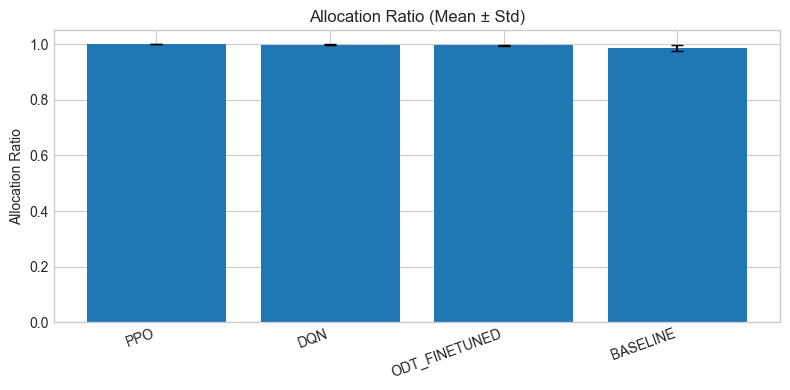

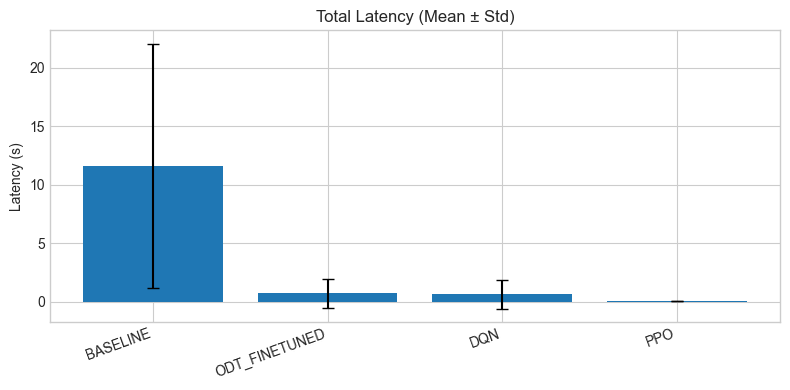

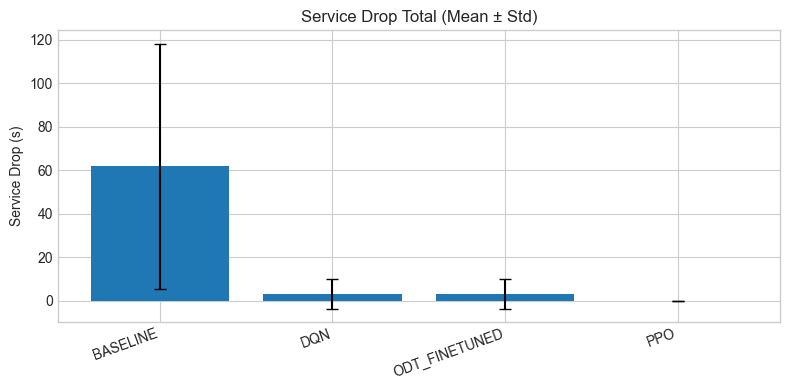

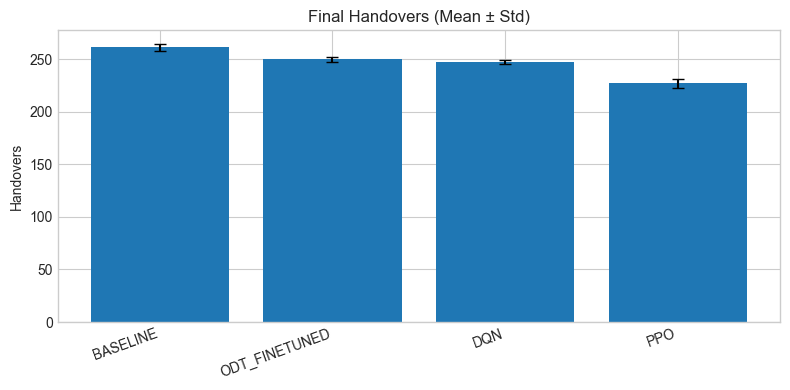

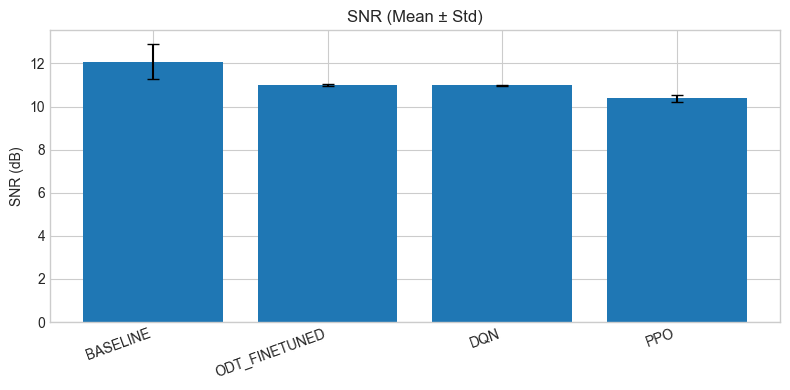

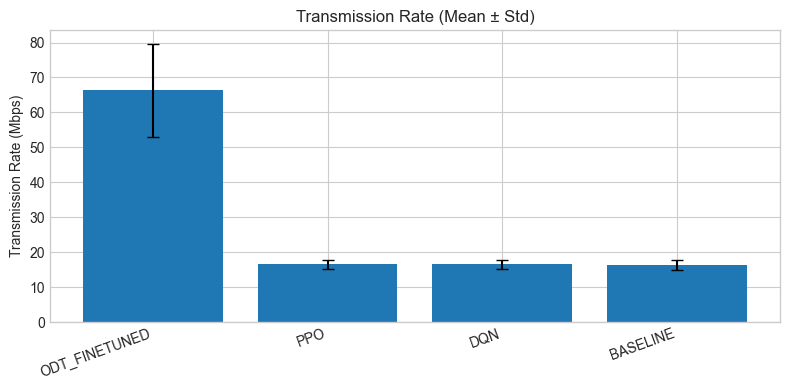

In [6]:

def plot_metric(summary_df, base_metric, ylabel, title):
    df = summary_df[['model', f'{base_metric}_mean', f'{base_metric}_std']].copy()
    df = df.sort_values(f'{base_metric}_mean', ascending=False)

    x = np.arange(len(df))
    y = df[f'{base_metric}_mean'].values
    e = df[f'{base_metric}_std'].fillna(0.0).values

    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x, y, yerr=e, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(df['model'].values, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_metric(summary, 'allocation_ratio_mean', 'Allocation Ratio', 'Allocation Ratio (Mean ± Std)')
plot_metric(summary, 'total_latency_mean', 'Latency (s)', 'Total Latency (Mean ± Std)')
plot_metric(summary, 'service_drop_total', 'Service Drop (s)', 'Service Drop Total (Mean ± Std)')
plot_metric(summary, 'handovers_final', 'Handovers', 'Final Handovers (Mean ± Std)')
plot_metric(summary, 'snr_mean', 'SNR (dB)', 'SNR (Mean ± Std)')
plot_metric(summary, 'transmission_rate_mean', 'Transmission Rate (Mbps)', 'Transmission Rate (Mean ± Std)')


## 5) Stepwise Averages Across Simulations

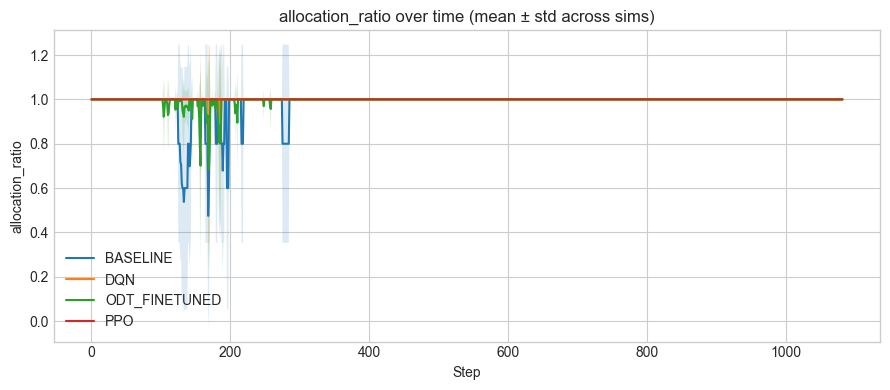

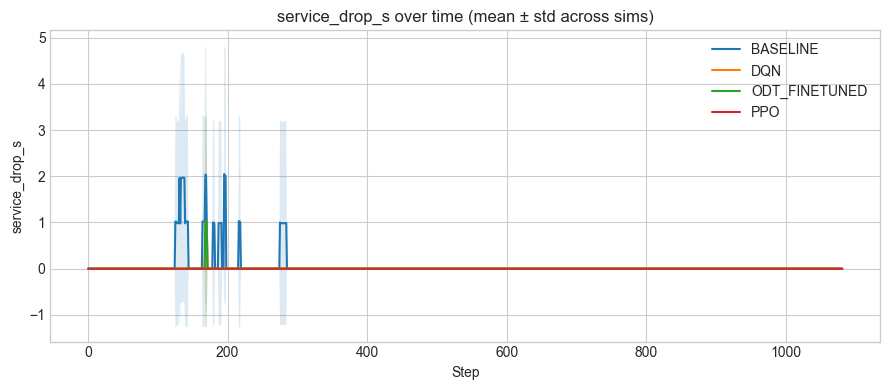

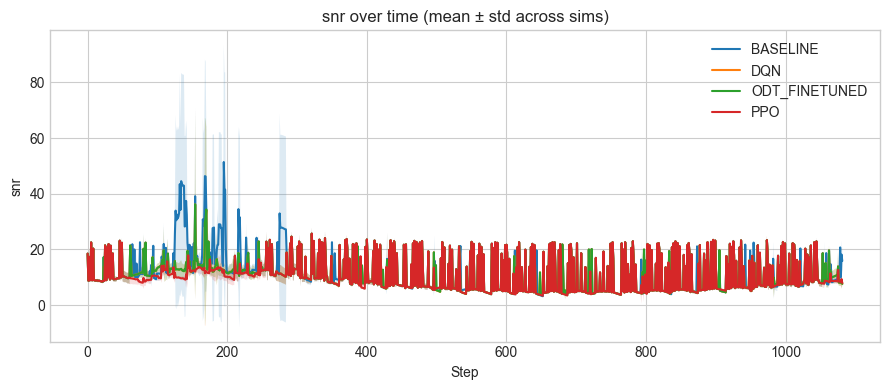

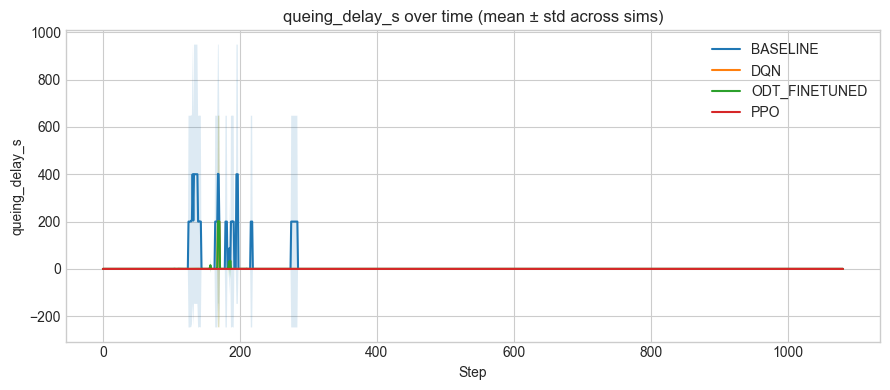

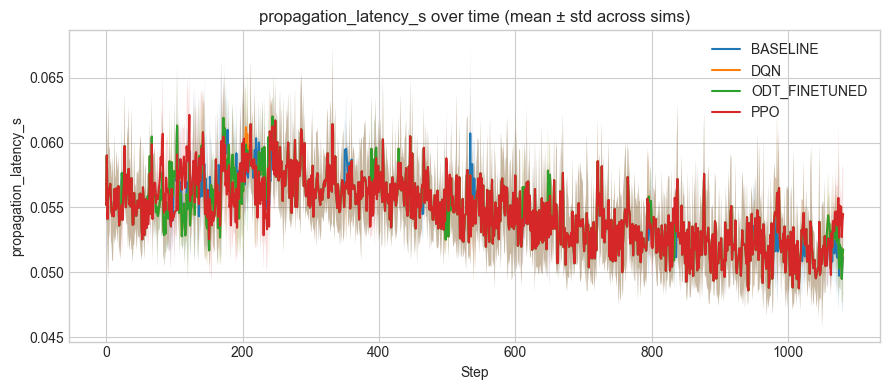

In [7]:

step_metrics = [
    'allocation_ratio',
    'service_drop_s',
    'snr',
    'queing_delay_s',
    'propagation_latency_s',
]

for metric in step_metrics:
    fig, ax = plt.subplots(figsize=(9,4))
    for model, g in all_df.groupby('model'):
        tmp = g.groupby(['sim','step'])[metric].mean().reset_index()
        agg = tmp.groupby('step')[metric].agg(['mean','std']).reset_index()
        ax.plot(agg['step'], agg['mean'], label=model)
        lo = agg['mean'] - agg['std'].fillna(0.0)
        hi = agg['mean'] + agg['std'].fillna(0.0)
        ax.fill_between(agg['step'], lo, hi, alpha=0.15)
    ax.set_title(f'{metric} over time (mean ± std across sims)')
    ax.set_xlabel('Step')
    ax.set_ylabel(metric)
    ax.legend()
    plt.tight_layout()
    plt.show()
